In [10]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
columns = ['Sepal Length' , 'Sepal Width' , 'Petal Length' , 'Petal Width' , 'Class_Labels']
df = pd.read_csv('/kaggle/input/datasets/nimishwadhwa06/iris-data/iris.data' ,names = columns)
df.head()


,Sepal Length,Sepal Width,Petal Length,Petal Width,Class_Labels
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [12]:
df.describe()

,Sepal Length,Sepal Width,Petal Length,Petal Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


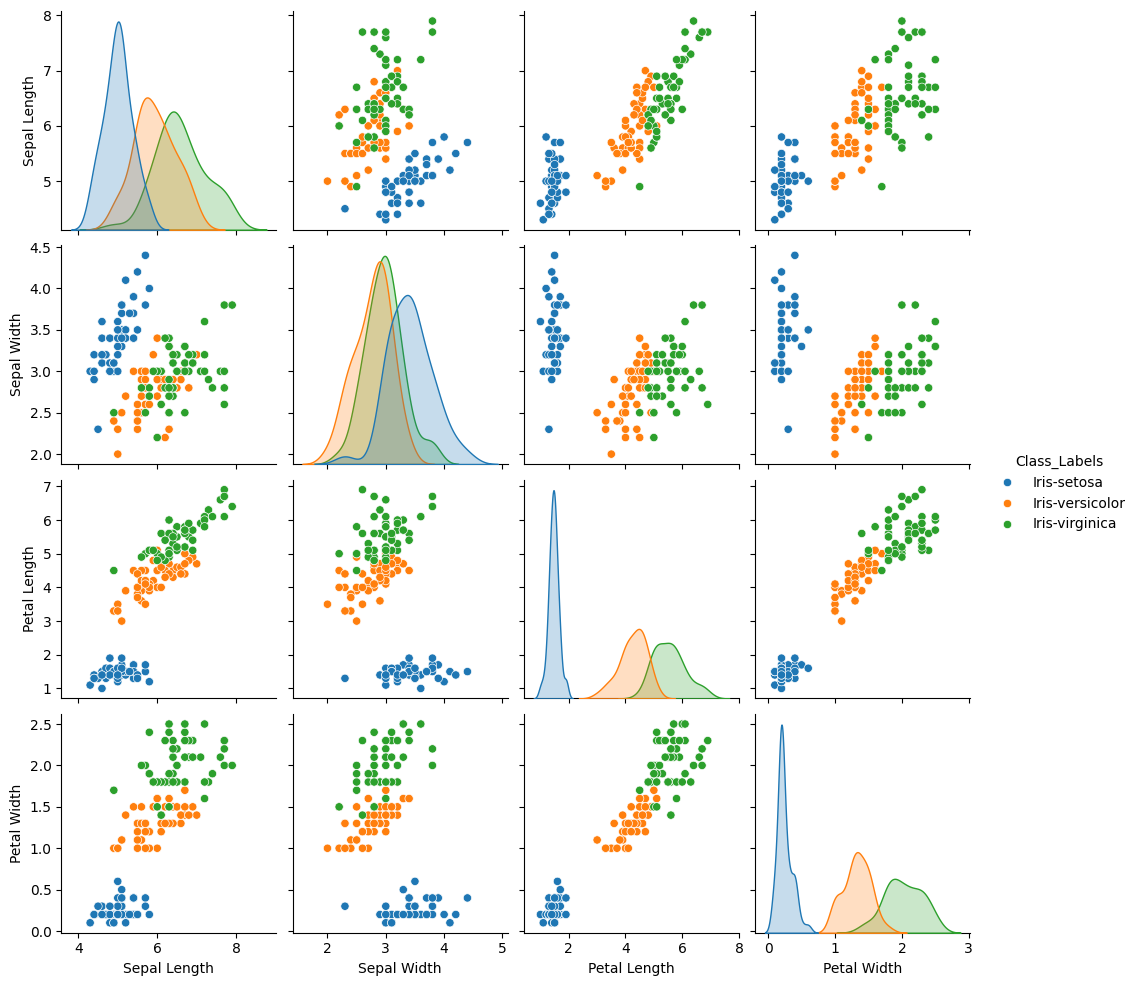

In [13]:
sns.pairplot(df, hue='Class_Labels')
plt.show()

In [14]:
data = df.values

In [15]:
X = data[:,0:4]
Y = data[:,4]

In [16]:
Y_Data = np.array([
    np.average(X[:,i][Y==j].astype('float32'))
    for i in range(X.shape[1])
    for j in (np.unique(Y))
])
Y_Data.reshape(4,3)

array([[5.006    , 5.9360003, 6.5880003],
       [3.418    , 2.7700002, 2.974    ],
       [1.4640001, 4.26     , 5.552    ],
       [0.244    , 1.3260001, 2.026    ]], dtype=float32)

In [17]:
Y_Data_reshaped = Y_Data.reshape(4, 3)
Y_Data_reshaped = np.swapaxes(Y_Data_reshaped, 0, 1)
X_axis = np.arange(len(columns)-1)
width = 0.25

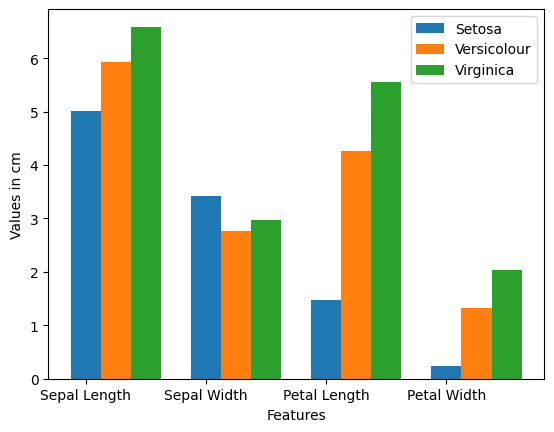

In [18]:
plt.bar(X_axis,Y_Data_reshaped[0],width,label = 'Setosa')
plt.bar(X_axis+width,Y_Data_reshaped[1],width,label = 'Versicolour')
plt.bar(X_axis+width*2,Y_Data_reshaped[2],width,label = 'Virginica')
plt.xticks(X_axis, columns[:4])
plt.xlabel("Features")
plt.ylabel("Values in cm")
plt.legend()
plt.show()


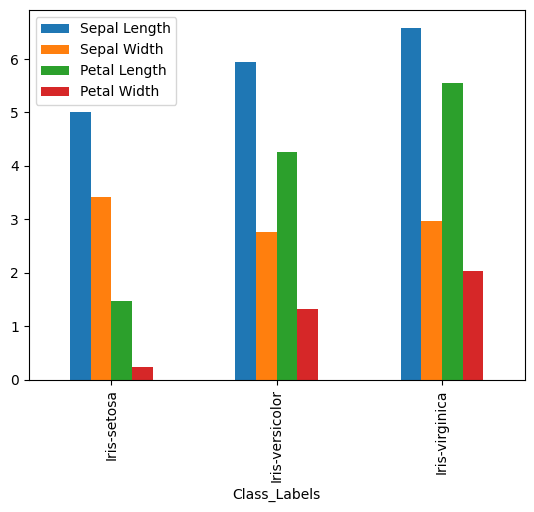

In [19]:
df.groupby('Class_Labels').mean().plot(kind='bar')

plt.show()

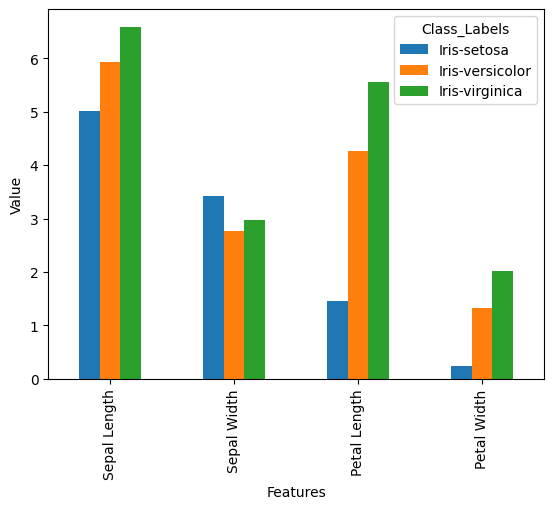

In [20]:
df.groupby('Class_Labels').mean().T.plot(kind='bar')

plt.xlabel("Features")
plt.ylabel("Value")
plt.show()

In [43]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [39]:
encoder = LabelEncoder()
Y_encoded = encoder.fit_transform(Y)

In [40]:
X_temp,X_test,Y_temp,Y_test = train_test_split(
    X,
    Y_encoded,
    test_size=0.2,
    random_state=42,
    stratify = Y,
)
X_train,X_val,Y_train,Y_val=train_test_split(
    X_temp,
    Y_temp,
    test_size=0.25,
    random_state=42,
    stratify=Y_temp
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# one hot encoding as we are training neural network too
Y_train_cat = to_categorical(Y_train)
Y_val_cat = to_categorical(Y_val)
Y_test_cat = to_categorical(Y_test)


### Neural Network

In [53]:
nn_model= Sequential([
    tf.keras.Input(shape=(4,)),
    Dense(16, activation='relu', name = 'layer1'),
    Dense(16, activation='relu', name = 'layer2'),
    Dense(3, activation='softmax', name = 'layer3'),
])
nn_model.compile(
    optimizer='adamW',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
nn_model.fit(
    X_train_scaled,
    Y_train_cat,
    epochs=50,
    batch_size=4,
    validation_data = (X_val_scaled,Y_val_cat)
)
nn_loss, nn_acc = nn_model.evaluate(
    X_test_scaled,
    Y_test_cat
)

print("Neural Network Accuracy:", nn_acc)
print("Neural Network Loss:", nn_loss)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1758 - loss: 1.0651 - val_accuracy: 0.3667 - val_loss: 1.0121
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6073 - loss: 0.9569 - val_accuracy: 0.8000 - val_loss: 0.9172
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8403 - loss: 0.8705 - val_accuracy: 0.8000 - val_loss: 0.8366
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8203 - loss: 0.7993 - val_accuracy: 0.8000 - val_loss: 0.7611
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9242 - loss: 0.6106 - val_accuracy: 0.8000 - val_loss: 0.6838
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8489 - loss: 0.6124 - val_accuracy: 0.8000 - val_loss: 0.6037
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8591 - loss: 0.5180 - val_accuracy: 0.8000 - val_loss: 0.5429
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8663 - loss: 0.4388 - val_accuracy: 0.8000 - val_loss

### Decision Tree

In [71]:
best_depth = 0
best_acc =0
for depth in range(1,10):
    dt_model = DecisionTreeClassifier(
    max_depth=depth,
    random_state=42
    )

    dt_model.fit(X_train, Y_train)
    val_acc = dt_model.score(X_val, Y_val)
    
    if val_acc>best_acc:
        best_acc=val_acc
        best_depth = depth

print("Best depth:",best_depth)

final_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

final_dt.fit(X_train, Y_train)

dt_acc = final_dt.score(X_test, Y_test)

print("Final Test Accuracy:", dt_acc)

Best depth: 4
Final Test Accuracy: 0.9333333333333333


### Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier
best_estimators = 0
best_acc =0
for estimators in range(1,10):
    rf_model = RandomForestClassifier(
    n_estimators=estimators,
    random_state=42
    )

    rf_model.fit(X_train, Y_train)
    val_acc = rf_model.score(X_val, Y_val)
    
    if val_acc>best_acc:
        best_acc=val_acc
        best_estimators= estimators

print("Best estimators:",best_estimators)

final_rf = RandomForestClassifier(
    n_estimators=best_estimators,
    random_state=42
)

final_rf.fit(X_train, Y_train)

rf_acc = final_rf.score(X_test, Y_test)

print("Final Test Accuracy:", rf_acc)

Best estimators: 3
Final Test Accuracy: 0.9333333333333333


In [73]:
print("\nModel Comparison")
print("------------------------")
print("Neural Network :", nn_acc)
print("Decision Tree  :", dt_acc)
print("Random Forest  :", rf_acc)


Model Comparison
------------------------
Neural Network : 0.8999999761581421
Decision Tree  : 0.9333333333333333
Random Forest  : 0.9333333333333333


In [75]:
X_new = np.array([[3, 2, 1, 0.2], [  4.9, 2.2, 3.8, 1.1 ], [  5.3, 2.5, 4.6, 1.9 ]])
prediction = final_rf.predict(X_new)
predicted_label = encoder.inverse_transform(prediction)

print(predicted_label)



['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [77]:
import joblib
# from tensorflow.keras.models import load_model

# Save models
joblib.dump(final_rf, "/kaggle/working/random_forest_model.pkl")

joblib.dump(final_dt, "/kaggle/working/decision_tree_model.pkl")

nn_model.save("/kaggle/working/iris_nn_model.keras")

joblib.dump(scaler, "/kaggle/working/scaler.pkl")

joblib.dump(encoder, "/kaggle/working/encoder.pkl")

['/kaggle/working/encoder.pkl']